In [1]:
import numpy as np
import bilby
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import corner
import json
import healpy as hp
import matplotlib.ticker as ticker
from matplotlib.patches import Patch
from matplotlib import rc
import os
os.environ["PATH"] += os.pathsep + "/Library/TeX/texbin"

# Your custom text color
mycolor = 'black'  # or e.g., '#fe9463', (0.996, 0.580, 0.388)
from matplotlib import rcParams
# Global style settings
rcParams.update({
    # Enable LaTeX rendering
    'text.usetex': True,

    # Font settings
    'font.family': 'sans-serif',
    'font.sans-serif': ['Open Sans'],  # Use Open Sans if available

    # Set all text and visual elements to use the custom color
    'text.color': mycolor,
    'axes.labelcolor': mycolor,
    'xtick.color': mycolor,
    'ytick.color': mycolor,
    'axes.edgecolor': mycolor,
    'grid.color': mycolor,
    'legend.edgecolor': mycolor,
    'legend.facecolor': 'none',
    'legend.labelcolor': mycolor,

    # Transparent backgrounds
    'figure.facecolor': 'none',
    'axes.facecolor': 'none',
})

if mycolor=='white':
    rcParams['savefig.transparent'] = True

import matplotlib as mpl
mpl.rcParams['figure.facecolor'] = 'none'
mpl.rcParams['axes.facecolor']   = 'none'
mpl.rcParams['savefig.facecolor'] = 'none'
# fix tick labels size
mpl.rcParams['xtick.labelsize'] = 18
mpl.rcParams['ytick.labelsize'] = 18


## GWs on N-body maps

In [2]:
ska_color_pink = '#d60068'
ska_color_intermediate = '#840068'
ska_color_purple = '#180068'
radio_color = '#f5e15f'

In [3]:
from matplotlib.colors import LinearSegmentedColormap
mycmap = LinearSegmentedColormap.from_list("my_cmap", [ska_color_purple, ska_color_pink, ska_color_pink, radio_color])

In [4]:
nside = 128 # original resolution of dm halos maps
npix  = hp.nside2npix(nside)

In [5]:
count_data = np.loadtxt('../../dm_halos_data/count_map_snapshot55_zmin0.19_zmax0.22_nside128.txt')
mean_count_per_pix= np.sum(count_data)/npix
count_map = (count_data - mean_count_per_pix)/mean_count_per_pix

In [6]:
prob_map = np.zeros(npix, dtype=float) 
prob_map = count_map - np.min(count_map)
prob_map = prob_map/np.sum(prob_map)

In [7]:
# randomly draw N GW samples accordingly to this probaility density map
np.random.seed(42) #fixing the seed to make result reproducible
N_gws = 10_000
list_pix = np.random.choice(np.arange(npix), N_gws, replace=False, p=prob_map)
list_pix_iso = np.random.choice(np.arange(npix), N_gws, replace=False)

In [8]:
# create GW map using the selected pixels
event_map = np.zeros(npix)
event_map[list_pix] = 1.

event_map_iso = np.zeros(npix)
event_map_iso[list_pix_iso] = 1.

In [9]:
# RA-DEC location of the events
theta,phi = hp.pix2ang(nside,list_pix)
ra = phi/np.pi*180.
dec = theta/np.pi*180. -90.

# RA-DEC location of the events
theta_iso,phi_iso = hp.pix2ang(nside,list_pix_iso)
ra_iso = phi_iso/np.pi*180.
dec_iso = theta_iso/np.pi*180. -90.

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Define your RA/Dec window
ra_min, ra_max = 0, 60      # example values in degrees
dec_min, dec_max = -30, 30     # example values in degrees

# Mask points inside the region
mask = (
    (ra >= ra_min) & (ra <= ra_max) &
    (dec >= dec_min) & (dec <= dec_max)
)

# Mask points inside the region
mask_iso = (
    (ra_iso >= ra_min) & (ra_iso <= ra_max) &
    (dec_iso >= dec_min) & (dec_iso <= dec_max)
)


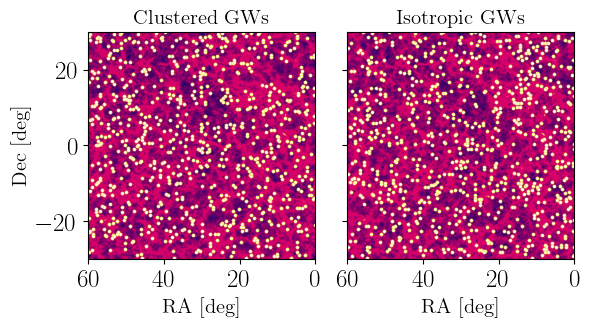

In [12]:
import healpy as hp
import matplotlib.pyplot as plt
import numpy as np


proj = hp.projector.CartesianProj(
    lonra=[ra_min, ra_max],
    latra=[dec_min, dec_max]
)

img = proj.projmap(
    count_map,
    lambda x, y, z: hp.vec2pix(hp.get_nside(count_map), x, y, z)
)

my_fontsize=15

fig, axes = plt.subplots(1, 2, figsize=(6, 4), sharey=True)

# =======================
# Left panel: Clustered
# =======================
axes[0].imshow(
    img,
    origin='upper',
    extent=[ra_min, ra_max, dec_min, dec_max],
    cmap=mycmap
)

axes[0].scatter(
    ra_min + ra_max - ra[mask], dec_min + dec_max - dec[mask],  # flip Dec
    color='white', s=5, marker='o',
    edgecolors=radio_color, linewidths=0.5
)

axes[0].set_title(r'\rm Clustered GWs', fontsize=my_fontsize)
axes[0].set_xlabel(r"\rm RA [deg]", fontsize=my_fontsize)
axes[0].set_ylabel(r"\rm Dec [deg]", fontsize=my_fontsize)


# =======================
# Right panel: Isotropic
# =======================
axes[1].imshow(
    img,
    origin='upper',
    extent=[ra_min, ra_max, dec_min, dec_max],
    cmap=mycmap
)

axes[1].scatter(
    ra_min + ra_max - ra_iso[mask_iso], dec_min + dec_max - dec_iso[mask_iso],  # flip Dec
    color='white', s=5, marker='o',
    edgecolors=radio_color, linewidths=0.5
)

axes[1].set_title(r'\rm Isotropic GWs', fontsize=my_fontsize)
axes[1].set_xlabel(r"\rm RA [deg]", fontsize=my_fontsize)

xticks = np.arange(0, 61, 20)

axes[0].set_xticks(xticks)
axes[0].set_xticklabels([f"${x}$" for x in xticks[::-1]], fontsize=18)

axes[1].set_xticks(xticks)
axes[1].set_xticklabels([f"${x}$" for x in xticks[::-1]], fontsize=18)

plt.tight_layout()
plt.savefig('clustered_vs_iso_highz.pdf', bbox_inches='tight')
plt.show()